In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [2]:
df2 = pd.read_csv("data/combined_data.csv")
print(df2.columns)
exclude = ["price", "id", "name", "description", "amenities", "num_reviews_sampled", "sentiment_label", "district", "district_group"]
all_features = [col for col in df2.columns if col not in exclude]


Index(['id', 'price', 'property_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'neighbourhood_cleansed', 'latitude', 'longitude',
       'minimum_nights', 'maximum_nights', 'instant_bookable',
       'availability_365', 'number_of_reviews', 'review_scores_rating',
       'review_scores_cleanliness', 'review_scores_location',
       'review_scores_value', 'reviews_per_month', 'host_is_superhost',
       'host_response_rate', 'host_total_listings_count', 'name',
       'description', 'amenities', 'room_type_Entire home/apt',
       'room_type_Hotel room', 'room_type_Private room',
       'room_type_Shared room', 'booked_days', 'booked_weekdays',
       'booked_weekenddays', 'booked_winter', 'booked_spring', 'booked_summer',
       'booked_fall', 'booked_range', 'num_reviews_sampled',
       'avg_sentiment_score', 'num_reviews_total', 'sentiment_label',
       'district_group', 'district'],
      dtype='object')


In [3]:
df2 = df2.join(
    pd.get_dummies(df2.pop("district_group"), prefix="district_group", dtype=int)
)

X_all = df2[all_features]
y_all = df2["price"]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

In [4]:
feature_sets = {
    "ohne_calendar": [f for f in all_features if not f.startswith("booked")],
    "nur_calendar": ["booked_days", "booked_winter", "booked_summer", "booked_spring", "booked_fall", "booked_weekdays", "booked_weekenddays"],
    "calendar_plus_basics": [f for f in all_features if not f.startswith("booked") ] + ["booked_spring", "booked_fall", "booked_summer", "booked_winter"],
    "calendar_plus_basics2": [f for f in all_features if not f.startswith("booked") ] +  [ "booked_weekdays", "booked_weekenddays"],
    "calendar_plus_basics3": [f for f in all_features if not f.startswith("booked") ] +  ["booked_days"],
    "calendar_plus_basics4": [f for f in all_features if not f.startswith("booked") and f != "availability_365" ] +  ["booked_range"],
    "calendar_plus_basics5": [f for f in all_features if not f.startswith("booked") and f != "availability_365" ] +  ["booked_range", "booked_summer"],
    "alle_features": all_features
}

results = []

for name, features in feature_sets.items():
    print(f"Teste Feature-Set: {name}")

    X_train = X_train_all[features]
    X_test = X_test_all[features]

    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train_all)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test_all, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_all, y_pred))

    results.append({
        "feature_set": name,
        "MAE": mae,
        "RMSE": rmse
    })

    #feature_importance = pd.Series(
    #model.feature_importances_,
    #index=X.columns
    #).sort_values(ascending=False)


    #feature_importance.plot(kind="barh")
    #plt.title(f"Feature Importance {name}")
    #plt.xlabel("Wichtigkeit")
    #plt.tight_layout()

# Ergebnisse anzeigen
results_df = pd.DataFrame(results)
print(results_df)

Teste Feature-Set: ohne_calendar
Teste Feature-Set: nur_calendar
Teste Feature-Set: calendar_plus_basics
Teste Feature-Set: calendar_plus_basics2
Teste Feature-Set: calendar_plus_basics3
Teste Feature-Set: calendar_plus_basics4
Teste Feature-Set: calendar_plus_basics5
Teste Feature-Set: alle_features
             feature_set        MAE        RMSE
0          ohne_calendar  41.506032   77.000336
1           nur_calendar  76.819196  117.900155
2   calendar_plus_basics  42.215241   77.430250
3  calendar_plus_basics2  41.886137   77.097374
4  calendar_plus_basics3  41.640044   76.780845
5  calendar_plus_basics4  42.028658   77.334055
6  calendar_plus_basics5  42.111025   77.647554
7          alle_features  42.353675   77.421996


In [7]:
features = feature_sets["calendar_plus_basics3"]

In [8]:
# Funktion zum Testen von Hyperparametern
def test_hyperparameter(param_name, param_values, features):
    mae_scores = []
    rmse_scores = []

    X_train = X_train_all[features]
    X_test = X_test_all[features]

    for val in param_values:
        print(val)

        # Basis-Parameter
        params = {
            "random_state": 42
        }

        if param_name != "n_estimators":
            params["n_estimators"] = 300

        # Den zu testenden Parameter setzen
        params[param_name] = val

        model = RandomForestRegressor(**params)
        model.fit(X_train, y_train_all)
        y_pred = model.predict(X_test)

        mae_scores.append(mean_absolute_error(y_test_all, y_pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y_test_all, y_pred)))

    print(mae_scores)
    print(rmse_scores)

    if param_name != "max_features":
        plt.figure(figsize=(10,5))
        plt.plot(param_values, mae_scores, marker="o", label="MAE")
        plt.plot(param_values, rmse_scores, marker="o", label="RMSE")
        plt.title(f"Einfluss von {param_name} auf MAE/RMSE")
        plt.xlabel(param_name)
        plt.ylabel("Fehler")
        plt.grid(True)
        plt.legend()
        plt.show()

50
100
200
300
400
[41.68390309555855, 41.71125841184388, 41.64004374158815, 41.57576043068641, 41.51586305518169]
[np.float64(76.76003369646277), np.float64(77.03014749836883), np.float64(76.78084544317268), np.float64(76.68408156297025), np.float64(76.68247116434296)]


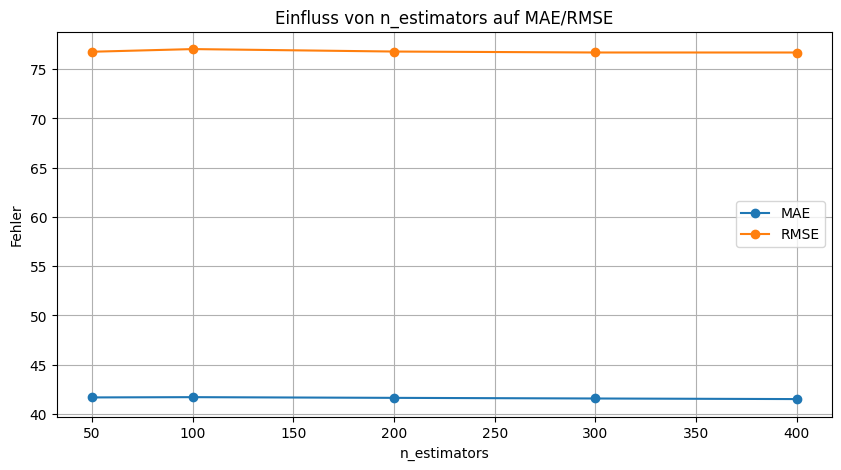

In [9]:
test_hyperparameter(
    "n_estimators",
    [50, 100, 200, 300, 400],
    feature_sets["calendar_plus_basics3"]
)

None
10
20
40
60
[41.57576043068641, 44.40017619786006, 41.839974199640636, 41.564999679548805, 41.57576043068641]
[np.float64(76.68408156297025), np.float64(78.90427402191375), np.float64(77.13833104070149), np.float64(76.67093528809728), np.float64(76.68408156297025)]


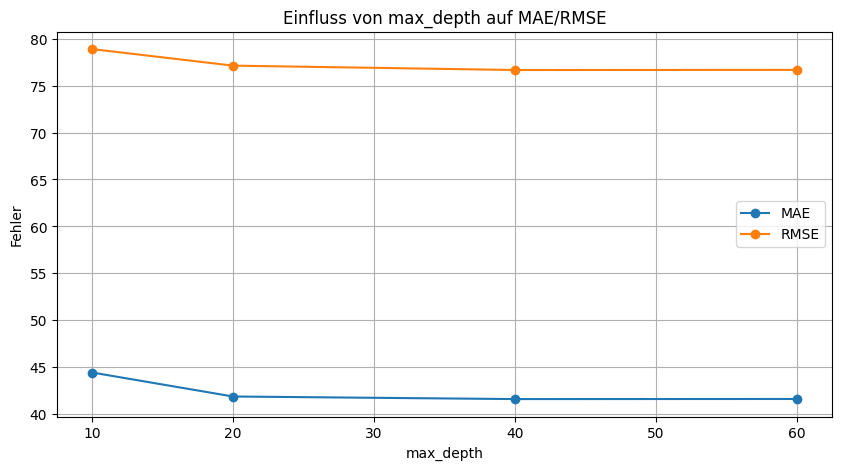

In [10]:
test_hyperparameter(
    "max_depth",
    [None, 10, 20, 40, 60],
    feature_sets["calendar_plus_basics3"]
)

2
5
10
20
[41.57576043068641, 41.74153093846734, 42.12092110223454, 42.448907367983026]
[np.float64(76.68408156297025), np.float64(76.675803117995), np.float64(77.10568859007022), np.float64(77.49406828646698)]


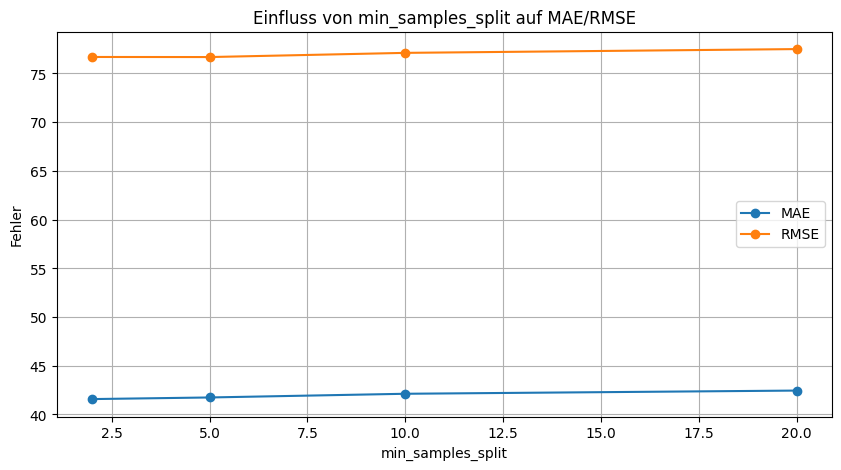

In [11]:
test_hyperparameter(
    "min_samples_split",
    [2, 5, 10, 20],
    feature_sets["calendar_plus_basics3"]
)

In [12]:
test_hyperparameter(
    "max_features",
    ["sqrt", "log2", None, 0.5],
    feature_sets["calendar_plus_basics3"]
)

sqrt
log2
None
0.5
[40.98596754897562, 41.33582323912068, 41.57576043068641, 40.92326603858232]
[np.float64(74.84280011288007), np.float64(75.48996184559692), np.float64(76.68408156297025), np.float64(75.46533071076533)]


MAE: 41.38547005462603
RMSE: 75.32212699361317


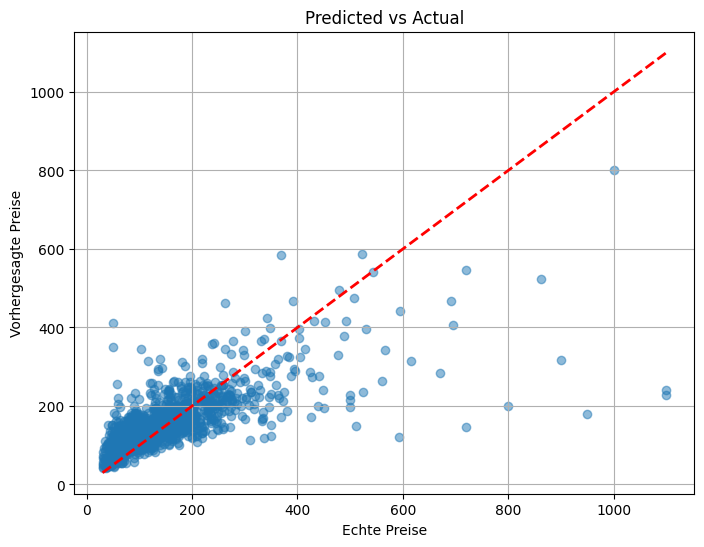

In [13]:
# daraus resultiert: n_estimator = 200, max_depth = 20, min_samples_split =2, max_features = sqrt

X_train = X_train_all[feature_sets["calendar_plus_basics3"]]
X_test = X_test_all[feature_sets["calendar_plus_basics3"]]

final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42
)

final_model.fit(X_train, y_train_all)
y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test_all, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_all, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(8,6))
plt.scatter(y_test_all, y_pred, alpha=0.5)
plt.plot([y_test_all.min(), y_test_all.max()],
         [y_test_all.min(), y_test_all.max()],
         "r--", lw=2)
plt.xlabel("Echte Preise")
plt.ylabel("Vorhergesagte Preise")
plt.title("Predicted vs Actual")
plt.grid(True)
plt.show()



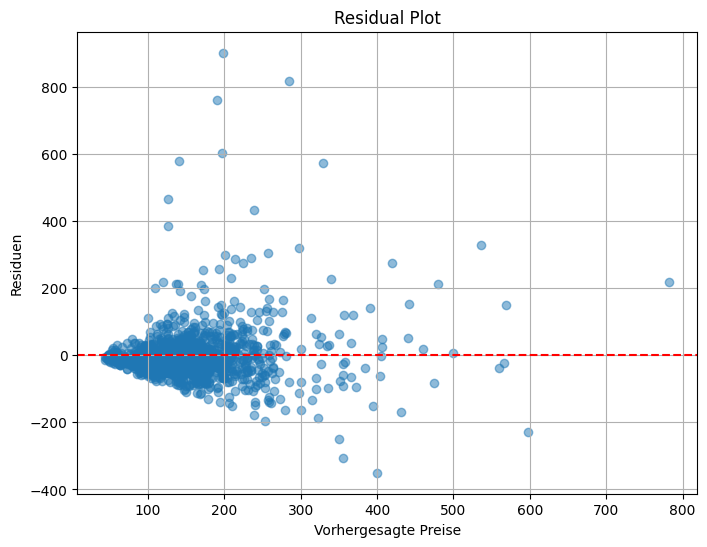

In [17]:
#Plot 2: Residuen‑Plot (Fehlerverteilung)
residuals = y_test_all - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Vorhergesagte Preise")
plt.ylabel("Residuen")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

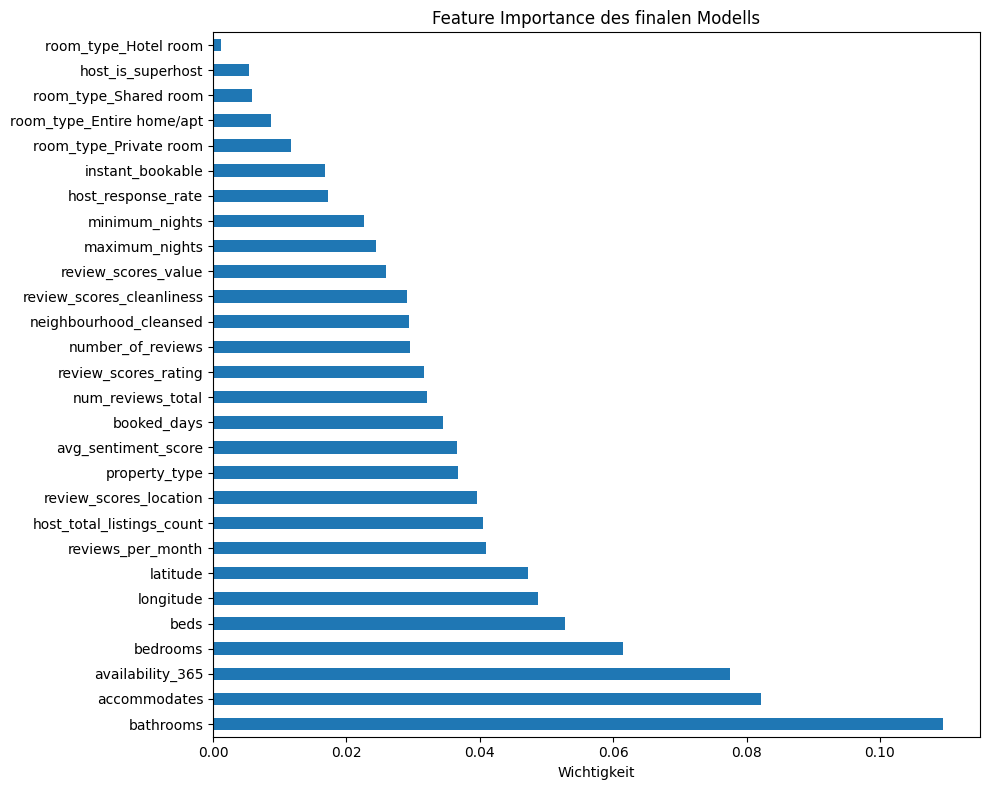

In [ ]:
# feature importance
importances = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))
importances.plot(kind="barh")
plt.title("Feature Importance des finalen Modells")
plt.xlabel("Wichtigkeit")
plt.tight_layout()
plt.show()



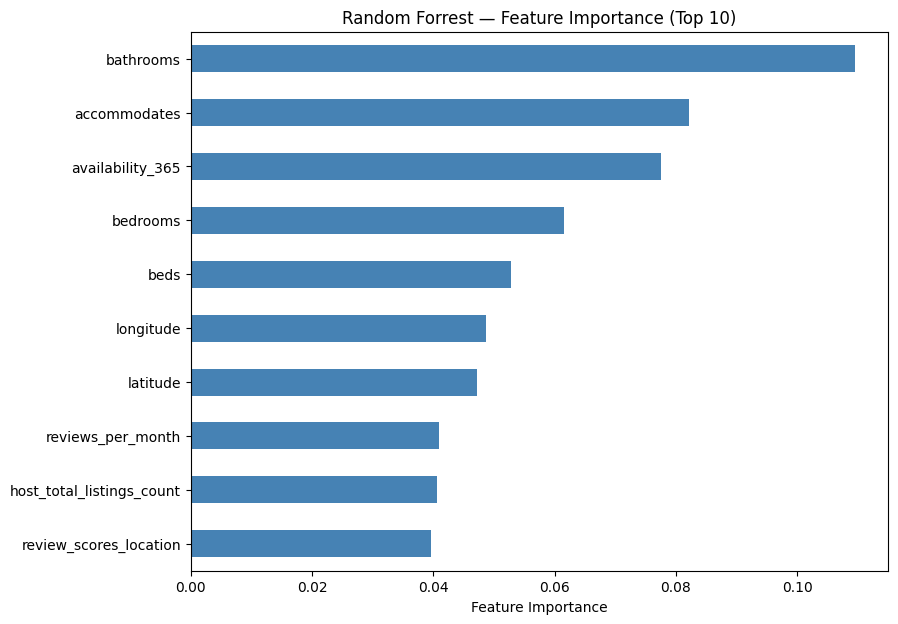

In [20]:
plt.figure(figsize=(9, 7))
importances.head(10).sort_values().plot(kind="barh", color="steelblue")
plt.title("Random Forrest — Feature Importance (Top 10)")
plt.xlabel("Feature Importance")
plt.savefig("feature_importance_xgboost.png")
plt.show()